### Import and Extraction od the Dataset 

In [105]:
!pip install openpyxl 

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
import sys
import os
from pathlib import Path
import importlib

sys.path.append(str(Path().resolve().parent))

# Importer avec le bon chemin
import Eda_analysis.data_inspection
importlib.reload(Eda_analysis.data_inspection)

# Importer depuis le même chemin
from Eda_analysis.data_inspection import DataInspection, DataTypeInspection,DataSummaryStaticticsInspection,DataMissingValuesInspection

import src.ingest_data
importlib.reload(src.ingest_data)
from src.ingest_data import DataIngestor, DataIngestorFactory



import Eda_analysis.univariate_analysis
importlib.reload(Eda_analysis.univariate_analysis)
from Eda_analysis.univariate_analysis import UnivariateAnalysisStrategy,UnivariateAnalyzer,NumericalUnivariateAnalysis,CategoricalUnivariateAnalysis


import config.ingestor_config
importlib.reload(config.ingestor_config)

import config.Paths
importlib.reload(config.Paths)
from config.Paths import ZIP_FILE



In [118]:
# check the file extension
file_path=ZIP_FILE
file_extension = os.path.splitext(file_path)[1]

In [119]:
from src.ingest_data import DataIngestorFactory

# 1. Créer l'ingestor
ingestor = DataIngestorFactory.get_data_ingestor(".zip")


df = ingestor.ingest(file_path)

print(df.shape)


(7043, 54)


# VARIABLES TYPE

In [ ]:
#basic types inspection strategy 
data_inspector= DataInspection(DataTypeInspection())
data_inspector.do_inspection(df)


 Types of variables of the Dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Count                              7043 non-null   int64  
 2   Gender                             7043 non-null   object 
 3   Age                                7043 non-null   int64  
 4   Under 30                           7043 non-null   object 
 5   Senior Citizen                     7043 non-null   object 
 6   Married                            7043 non-null   object 
 7   Dependents                         7043 non-null   object 
 8   Number of Dependents               7043 non-null   int64  
 9   Country                            7043 non-null   object 
 10  State                              7043 non-null   object 
 11  City              

# 📊 Data Inspection — Dataset Telco IBM (Complet)

## Vue Générale

- **7 043 clients**, **54 colonnes**
- **Aucune valeur manquante** sur la majorité des colonnes
- **Types** : 8 float64, 14 int64, 32 object

---

##  Valeurs Manquantes

| Colonne | Non-Null | Manquant | Interprétation |
|---|---|---|---|
| `Offer` | 3166/7043 | ~55% | Normal — tous les clients n'ont pas accepté une offre marketing |
| `Internet Type` | 5517/7043 | ~22% | Normal — les clients sans internet n'ont pas de type |
| `Churn Category` | 1869/7043 | ~73% | Normal — uniquement renseigné pour les clients qui ont churné |
| `Churn Reason` | 1869/7043 | ~73% | Même logique que Churn Category |

> Ces valeurs manquantes sont **métier** et non des erreurs de données — elles ne nécessitent pas d'imputation systématique.

---

##  Colonnes à Examiner

| Colonne | Problème | Action |
|---|---|---|
| `Count` | Variable technique pour dashboards | À dropper |
| `Quarter` | Toujours Q3 — aucune variance | À dropper |
| `Country` | Toujours "United States" | À dropper |
| `State` | Toujours "California" | À dropper |
| `Lat Long` | Redondant avec `Latitude` et `Longitude` | À dropper |
| `Under 30` | Redondant avec `Age` | À examiner |
| `Churn Label` | Redondant avec `Churn Value` | À dropper |
| `ID` | Clé technique issue de la table population | À dropper |

---

##  Notre Variable Cible

```python
df["Satisfaction Score"].value_counts()
```

- **Type** : int64 
- **7043 non-null** — aucune valeur manquante ✅
- Score de 1 à 5 — à regrouper en 3 classes (Detractor / Neutral / Promoter)

---

##  Organisation des Colonnes par Groupe

### 👤 Identification
`Customer ID`, `ID`

### 🧍 Démographie
`Gender`, `Age`, `Under 30`, `Senior Citizen`, `Married`, `Dependents`, `Number of Dependents`

### 📍 Localisation
`Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude`, `Population`

### 🤝 Relation Client
`Quarter`, `Referred a Friend`, `Number of Referrals`, `Tenure in Months`, `Offer`

### 📞 Services Téléphoniques
`Phone Service`, `Avg Monthly Long Distance Charges`, `Multiple Lines`

### 🌐 Services Internet
`Internet Service`, `Internet Type`, `Avg Monthly GB Download`, `Online Security`,
`Online Backup`, `Device Protection Plan`, `Premium Tech Support`,
`Streaming TV`, `Streaming Movies`, `Streaming Music`, `Unlimited Data`

### 💳 Contrat & Facturation
`Contract`, `Paperless Billing`, `Payment Method`, `Monthly Charge`,
`Total Charges`, `Total Refunds`, `Total Extra Data Charges`,
`Total Long Distance Charges`, `Total Revenue`

### 🎯 Variables Cibles & Scores
`Satisfaction Score` ⭐, `Customer Status`, `Churn Label`, `Churn Value`,
`Churn Score`, `CLTV`, `Churn Category`, `Churn Reason`

---

# SUMMARY STATISTICS

In [127]:

#do statistics description of the dataset
data_inspector.set_strategy(DataSummaryStaticticsInspection())
data_inspector.do_inspection(df)


 Summary Statitics for numerical features :
        Count          Age  Number of Dependents      Zip Code     Latitude    Longitude  Number of Referrals  Tenure in Months  Avg Monthly Long Distance Charges  Avg Monthly GB Download  Monthly Charge  Total Charges  Total Refunds  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  Satisfaction Score  Churn Value  Churn Score         CLTV           ID     Population
count  7043.0  7043.000000           7043.000000   7043.000000  7043.000000  7043.000000          7043.000000       7043.000000                        7043.000000              7043.000000     7043.000000    7043.000000    7043.000000               7043.000000                  7043.000000    7043.000000         7043.000000  7043.000000  7043.000000  7043.000000  7043.000000    7043.000000
mean      1.0    46.509726              0.468692  93486.070567    36.197455  -119.756684             1.951867         32.386767                          22.958954           

# 📊 Summary Statistics

---

## 1. Variables Numériques

### 🧍 Démographie

**`Age`**
- Moyenne : **46.5 ans**, min 19, max 80
- Distribution assez équilibrée — les clients sont répartis sur toutes les tranches d'âge
- 25% des clients ont moins de 32 ans, 75% moins de 60 ans

**`Number of Dependents`**
- Moyenne très faible : **0.47** — la majorité des clients n'ont pas de personnes à charge
- Max = 9 — quelques familles nombreuses mais très rares
- 75ème percentile = 0 → plus de 75% des clients ont 0 dépendants

---

### 🤝 Relation Client

**`Number of Referrals`**
- Moyenne : **1.95** recommandations par client
- 50% des clients n'ont fait **aucune recommandation** (médiane = 0)
- Max = 11 — quelques clients très ambassadeurs
- ⚠️ Distribution très asymétrique — la majorité ne recommande pas et 75 %ont moins de 3  recommandations

**`Tenure in Months`**
- Moyenne : **32.4 mois** (~2.7 ans)
- Min = 1 mois, Max = 72 mois (6 ans)
- 25% des clients sont là depuis moins de **9 mois** → beaucoup de nouveaux clients
- 50% depuis moins de **29 mois**
- 💡 **Insight** : grosse proportion de clients récents — risque de churn élevé sur cette population

---

### 📞 Services Téléphoniques

**`Avg Monthly Long Distance Charges`**
- Moyenne : **22.96€/mois**
- Min = 0 → certains clients n'utilisent pas du tout la longue distance
- Max = 49.99€
- 💡 **Insight** : les clients qui paient 0 en longue distance n'ont probablement pas le service téléphonique actif

---

### 🌐 Services Internet

**`Avg Monthly GB Download`**
- Moyenne : **20.5 GB/mois**
- Min = 0 → clients sans internet
- Max = 85 GB → gros consommateurs (streamers, gamers...)
- 💡 **Insight** : forte disparité d'usage — segmentation possible entre petits et gros consommateurs

---

### 💳 Facturation & Charges

**`Monthly Charge`**
- Moyenne : **64.76€/mois**
- Min = 18.25€ (forfait très basique), Max = 118.75€ (forfait premium complet)
- 25% paient moins de **35.50€** → clients avec peu de services
- 75% paient moins de **89.85€**
- 💡 **Insight** : bonne variance — les services souscrits influencent fortement la charge mensuelle

**`Total Charges`**
- Moyenne : **2280€**, Max = **8684€**
- Très corrélé avec le Tenure — plus un client est ancien, plus il a payé
- 25% ont payé moins de **400€** → clients récents ou peu actifs
- 💡 **Insight** : Créér une variable qui mésure l'evolution des charges pour le clients, sil ya upgradé ou non, 
Monthly charge cest les charges menseuls actules du client, Total charges , cest ce quil a payé depuis qu'il es client, un petit calculs nous permet de savoir si ses charges mensuels actuels ont diminué ou augmenté pour savoir si il souscrit a moins de services ou non ( A verifier 
)

**`Total Refunds`**
- Moyenne très faible : **1.96€**, Max = **49.79€**
- 75ème percentile = 0 → **la majorité des clients n'a jamais été remboursée**
- 💡 **Insight** : les clients avec des remboursements élevés ont probablement eu des problèmes de service → à croiser avec le Satisfaction Score

**`Total Extra Data Charges`**
- Moyenne : **6.86€**, Max = **150€**
- 75ème percentile = 0 → la majorité ne dépasse jamais son quota
- 💡 **Insight** : les clients qui paient des extras data n'ont pas Unlimited Data — potentielle source d'insatisfaction

**`Total Long Distance Charges`**
- Moyenne : **749€** sur toute la durée
- Très variable (std = 846) — certains clients n'utilisent jamais, d'autres beaucoup
- Max = **3564€** → clients très intensifs en longue distance

**`Total Revenue`**
- Moyenne : **3034€** par client sur toute sa durée de vie
- Max = **11 979€** — clients très précieux
- 💡 **Insight** : combiné au Satisfaction Score, identifie les clients à haute valeur et insatisfaits → priorité absolue de rétention

---

### 🎯 Scores & Variables Cibles

**`Satisfaction Score`** ⭐
- Moyenne : **3.24 / 5**
- Min = 1, Max = 5 — toute l'échelle est utilisée
- 25ème percentile = 3, médiane = 3, 75ème percentile = 4
- 💡 **Insight** : la distribution est centrée sur 3 — beaucoup de clients neutres, ce qui
confirme l'intérêt de notre classification à 3 classes (Detractor / Neutral / Promoter)

**`Churn Value`**
- Moyenne : **0.265** → **26.5% des clients ont churné** ce trimestre
- C'est un taux de churn élevé — normal pour du Month-to-Month
- 💡 **Insight** : à croiser avec le Satisfaction Score pour valider que les insatisfaits churent plus

**`Churn Score`**
- Moyenne : **58.5 / 100**, Max = 96
- 25ème percentile = 40, 75ème = 75.5
- 💡 **Insight** : beaucoup de clients ont un score de churn élevé — le modèle IBM les considère à risque

**`CLTV`**
- Moyenne : **4400€**, Min = 2003€, Max = 6500€
- Distribution relativement resserrée — pas de clients extrêmement outliers en valeur
- 💡 **Insight** : un client CLTV élevé + Satisfaction Score bas = signal critique à traiter en priorité

---

## 2. Variables Catégorielles

### 🧍 Démographie

**`Gender`**
- 2 modalités : Male (3555) / Female
- Légère majorité masculine mais distribution presque équilibrée (~50/50)

**`Under 30`**
- 5642 clients ont "No" → seulement **~20% des clients ont moins de 30 ans**
- Cohérent avec la moyenne d'âge de 46.5 ans

**`Senior Citizen`**
- 5901 "No" → seulement **~16% de seniors**
- Les seniors sont minoritaires mais potentiellement un segment à surveiller

**`Married`**
- 3641 "No" → **~48% de clients mariés** — presque équilibré

**`Dependents`**
- 5416 "No" → **~23% des clients ont des personnes à charge**
- Cohérent avec `Number of Dependents` moyen très faible

---

### 📍 Localisation

**`Country` / `State`**
- Toujours "United States" / "California" → **aucune variance, à dropper**

**`City`**
- 1106 villes uniques
- Top : Los Angeles (293 clients) — city la plus représentée mais pas dominante
- Distribution géographique assez dispersée en Californie

---

### 🤝 Relation Client

**`Quarter`**
- Toujours "Q3" → **aucune variance, à dropper**

**`Referred a Friend`**
- 3821 "No" → **~46% des clients ont déjà recommandé** — c'est significatif
- Cohérent avec `Number of Referrals` moyen de 1.95

**`Offer`**
- Seulement **3166 clients** sur 7043 ont une offre → 55% sans offre
- Top : Offer B (824 clients)
- 💡 **Insight** : à croiser avec le Satisfaction Score — certaines offres retiennent-elles mieux ?

---

### 📞 Services

**`Phone Service`**
- 6361 "Yes" → **90% des clients ont le téléphone** — service quasi universel

**`Multiple Lines`**
- 4072 "No" → seulement **~42% ont plusieurs lignes**

**`Internet Service`**
- 5517 "Yes" → **~78% ont internet** — service très répandu

**`Internet Type`**
- 3035 "Fiber Optic" sur 5517 → **55% des abonnés internet ont la fibre**
- 💡 **Insight** : la fibre est majoritaire — à surveiller car souvent liée à des attentes élevées et plus de plaintes

---

### 📦 Options Internet

| Option | Souscrit (Yes) | Non souscrit (No) | Taux de souscription |
|---|---|---|---|
| `Online Security` | 2019 | 5024 | ~29% |
| `Online Backup` | 2429 | 4614 | ~34% |
| `Device Protection Plan` | 2422 | 4621 | ~34% |
| `Premium Tech Support` | 2044 | 4999 | ~29% |
| `Streaming TV` | 2707 | 4336 | ~38% |
| `Streaming Movies` | 2732 | 4311 | ~39% |
| `Streaming Music` | 2488 | 4555 | ~35% |
| `Unlimited Data` | 2298 | 4745 | ~33% |

💡 **Insight** : les options de sécurité et support premium ont les taux de souscription les plus bas — pourtant ce sont celles qui impactent le plus la satisfaction perçue

---

### 💳 Contrat & Paiement

**`Contract`**
- Month-to-Month : **3610 clients** (~51%) → majorité en contrat court
- 💡 **Insight critique** : plus de la moitié des clients peuvent partir à tout moment — directement lié au taux de churn de 26.5%

**`Paperless Billing`**
- 4171 "Yes" → **~59% utilisent la facturation dématérialisée** — profil digital majoritaire

**`Payment Method`**
- Bank Withdrawal : **3909** (~55%) — mode de paiement dominant
- Credit Card : ~27%
- Mailed Check : ~18% → profil moins digital, souvent plus ancien

---

### 🎯 Variables Cibles

**`Customer Status`**
- Stayed : **4720** (~67%)
- Churned : **1869** (~27%)
- Joined : **454** (~6%)
- 💡 **Insight** : 27% de churn sur un seul trimestre c'est très élevé — confirme l'urgence du projet

**`Churn Category`**
- Seulement 1869 renseignés (les churners)
- Top : **Competitor** (841) → la raison principale de départ c'est la concurrence
- Ensuite : Attitude, Dissatisfaction, Price, Other
- 💡 **Insight** : si les clients partent surtout vers la concurrence, le pricing et les offres sont les leviers prioritaires

**`Churn Reason`**
- 20 raisons uniques
- Top : **"Competitor had better devices"** (313) 
- 💡 **Insight** : les clients comparent activement les équipements proposés — argument matériel fort chez les concurrents

---

## 🔑 Synthèse des Insights Clés

| # | Insight | Impact |
|---|---|---|
| 1 | 26.5% de churn sur un trimestre — taux très élevé | 🔴 Critique |
| 2 | 51% de clients en Month-to-Month — instabilité maximale | 🔴 Critique |
| 3 | Satisfaction Score centré sur 3 — beaucoup de neutrals à convertir | 🟠 Important |
| 4 | La concurrence est la 1ère raison de départ | 🟠 Important |
| 5 | 55% des clients internet ont la fibre — attentes élevées | 🟡 À surveiller |
| 6 | Options sécurité et support peu souscrites mais très impactantes | 🟡 À surveiller |
| 7 | Clients récents (<9 mois) très nombreux — segment fragile | 🟡 À surveiller |

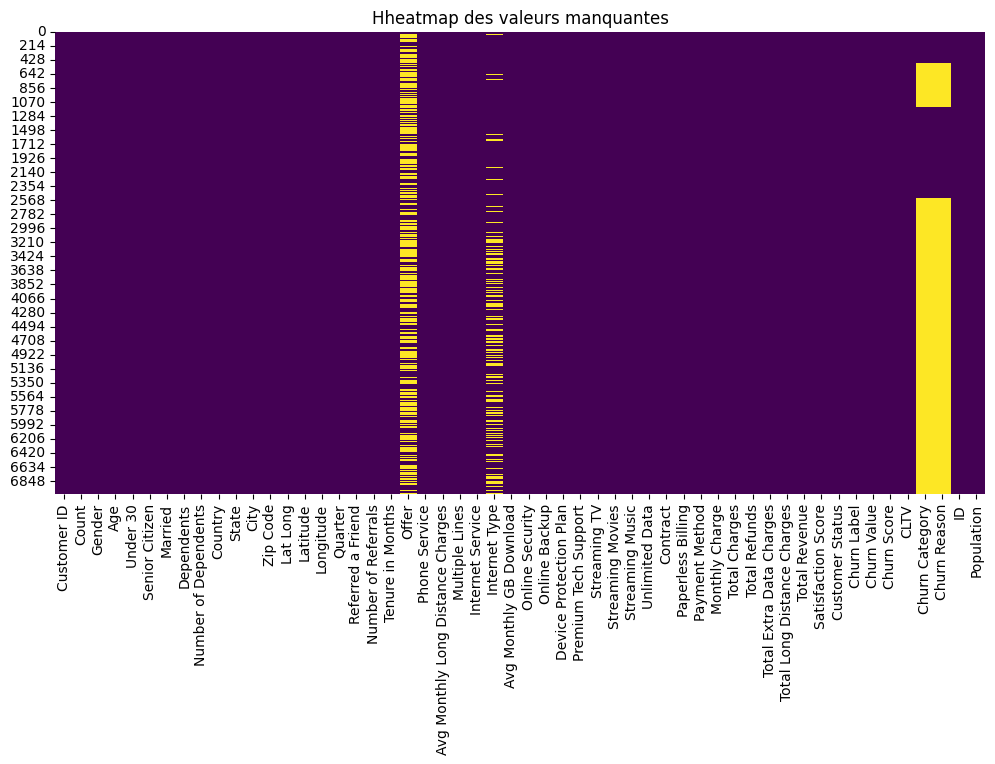

In [130]:
data_inspector.set_strategy(DataMissingValuesInspection())
data_inspector.do_inspection(df)

# 📊 Analyse des Valeurs Manquantes

## Heatmap

La heatmap ci-dessus représente les valeurs manquantes du dataset.
Elle ne fait que confirmé ce qu'on a dit au plus haut 
- **Violet** → colonne complète, aucune valeur manquante
- **Jaune** → valeurs manquantes

---

## Zones Jaunes Identifiées

### `Offer` — ~55% de manquants
Les clients sans valeur ici n'ont simplement **pas d'offre marketing active**.
Ce n'est pas une erreur de collecte.

### `Internet Type` — ~22% de manquants
Les clients sans valeur ici **n'ont pas souscrit à internet**.
Pas de service = pas de type de connexion, c'est logique.

### `Churn Category` et `Churn Reason` — ~73% de manquants
Ces colonnes ne sont renseignées **que pour les clients qui ont churné**
soit 1869 clients sur 7043.
Les 5174 restants sont des clients actifs ou nouveaux — leur absence de
valeur est donc parfaitement normale.

---

## Conclusion

Toutes les valeurs manquantes sont **métier** — elles ont une signification
business précise et ne sont pas des erreurs de collecte de données.

| Colonne | Manquant signifie | Action |
|---|---|---|
| `Offer` | Client sans offre active | Imputer "No Offer" |
| `Internet Type` | Client sans internet | Imputer "No Internet" |
| `Churn Category` | Client non churné | Garder NaN — non concerné |
| `Churn Reason` | Client non churné | Garder NaN — non concerné |

> ⚠️ Aucune imputation statistique (moyenne, médiane...) n'est nécessaire
> ici. Ces valeurs manquantes seront traitées intelligemment dans l'étape
> de **preprocessing** selon leur signification métier.

# UNIVARIATE ANALYSIS

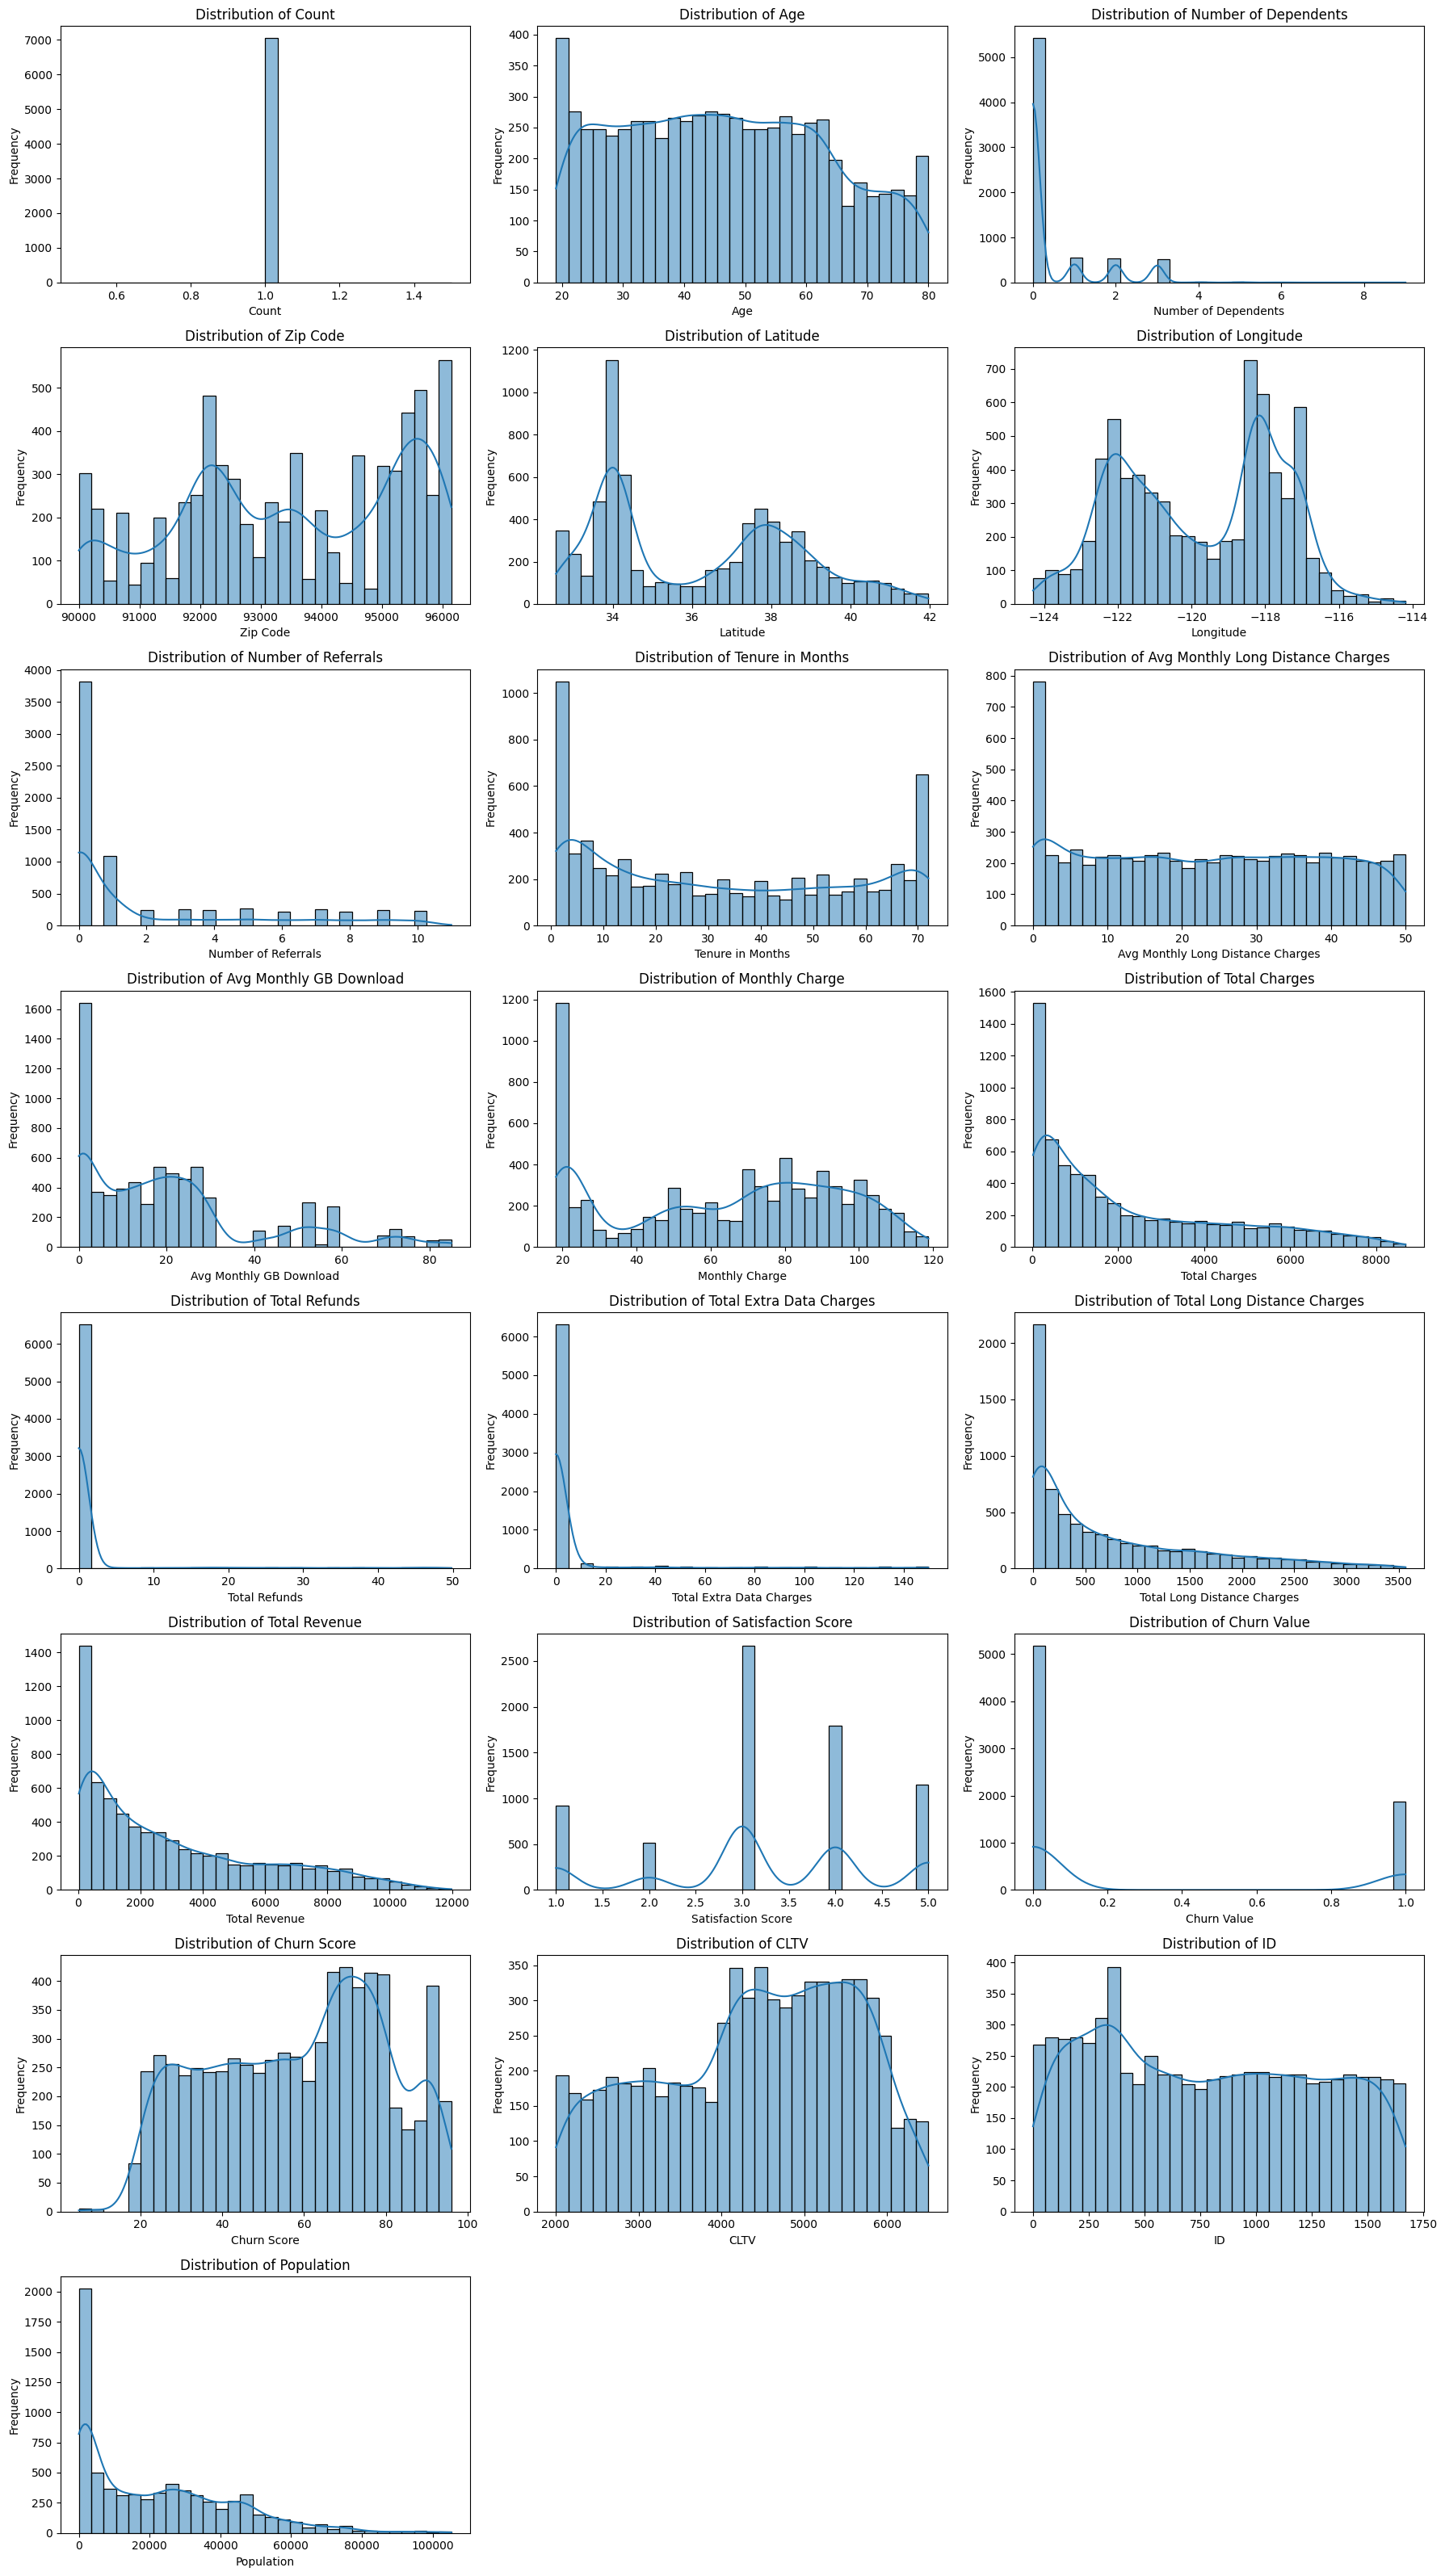

In [136]:
analyzer = UnivariateAnalyzer(NumericalUnivariateAnalysis())

# Toutes les variables numériques
analyzer.execute_analysis(df)




C:\Users\beugre niamba\Desktop\NPS-prediction\NPS-Prediction\Eda_analysis\univariate_analysis.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=data, palette="muted", ax=axes[i])
C:\Users\beugre niamba\Desktop\NPS-prediction\NPS-Prediction\Eda_analysis\univariate_analysis.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=data, palette="muted", ax=axes[i])
C:\Users\beugre niamba\Desktop\NPS-prediction\NPS-Prediction\Eda_analysis\univariate_analysis.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.count

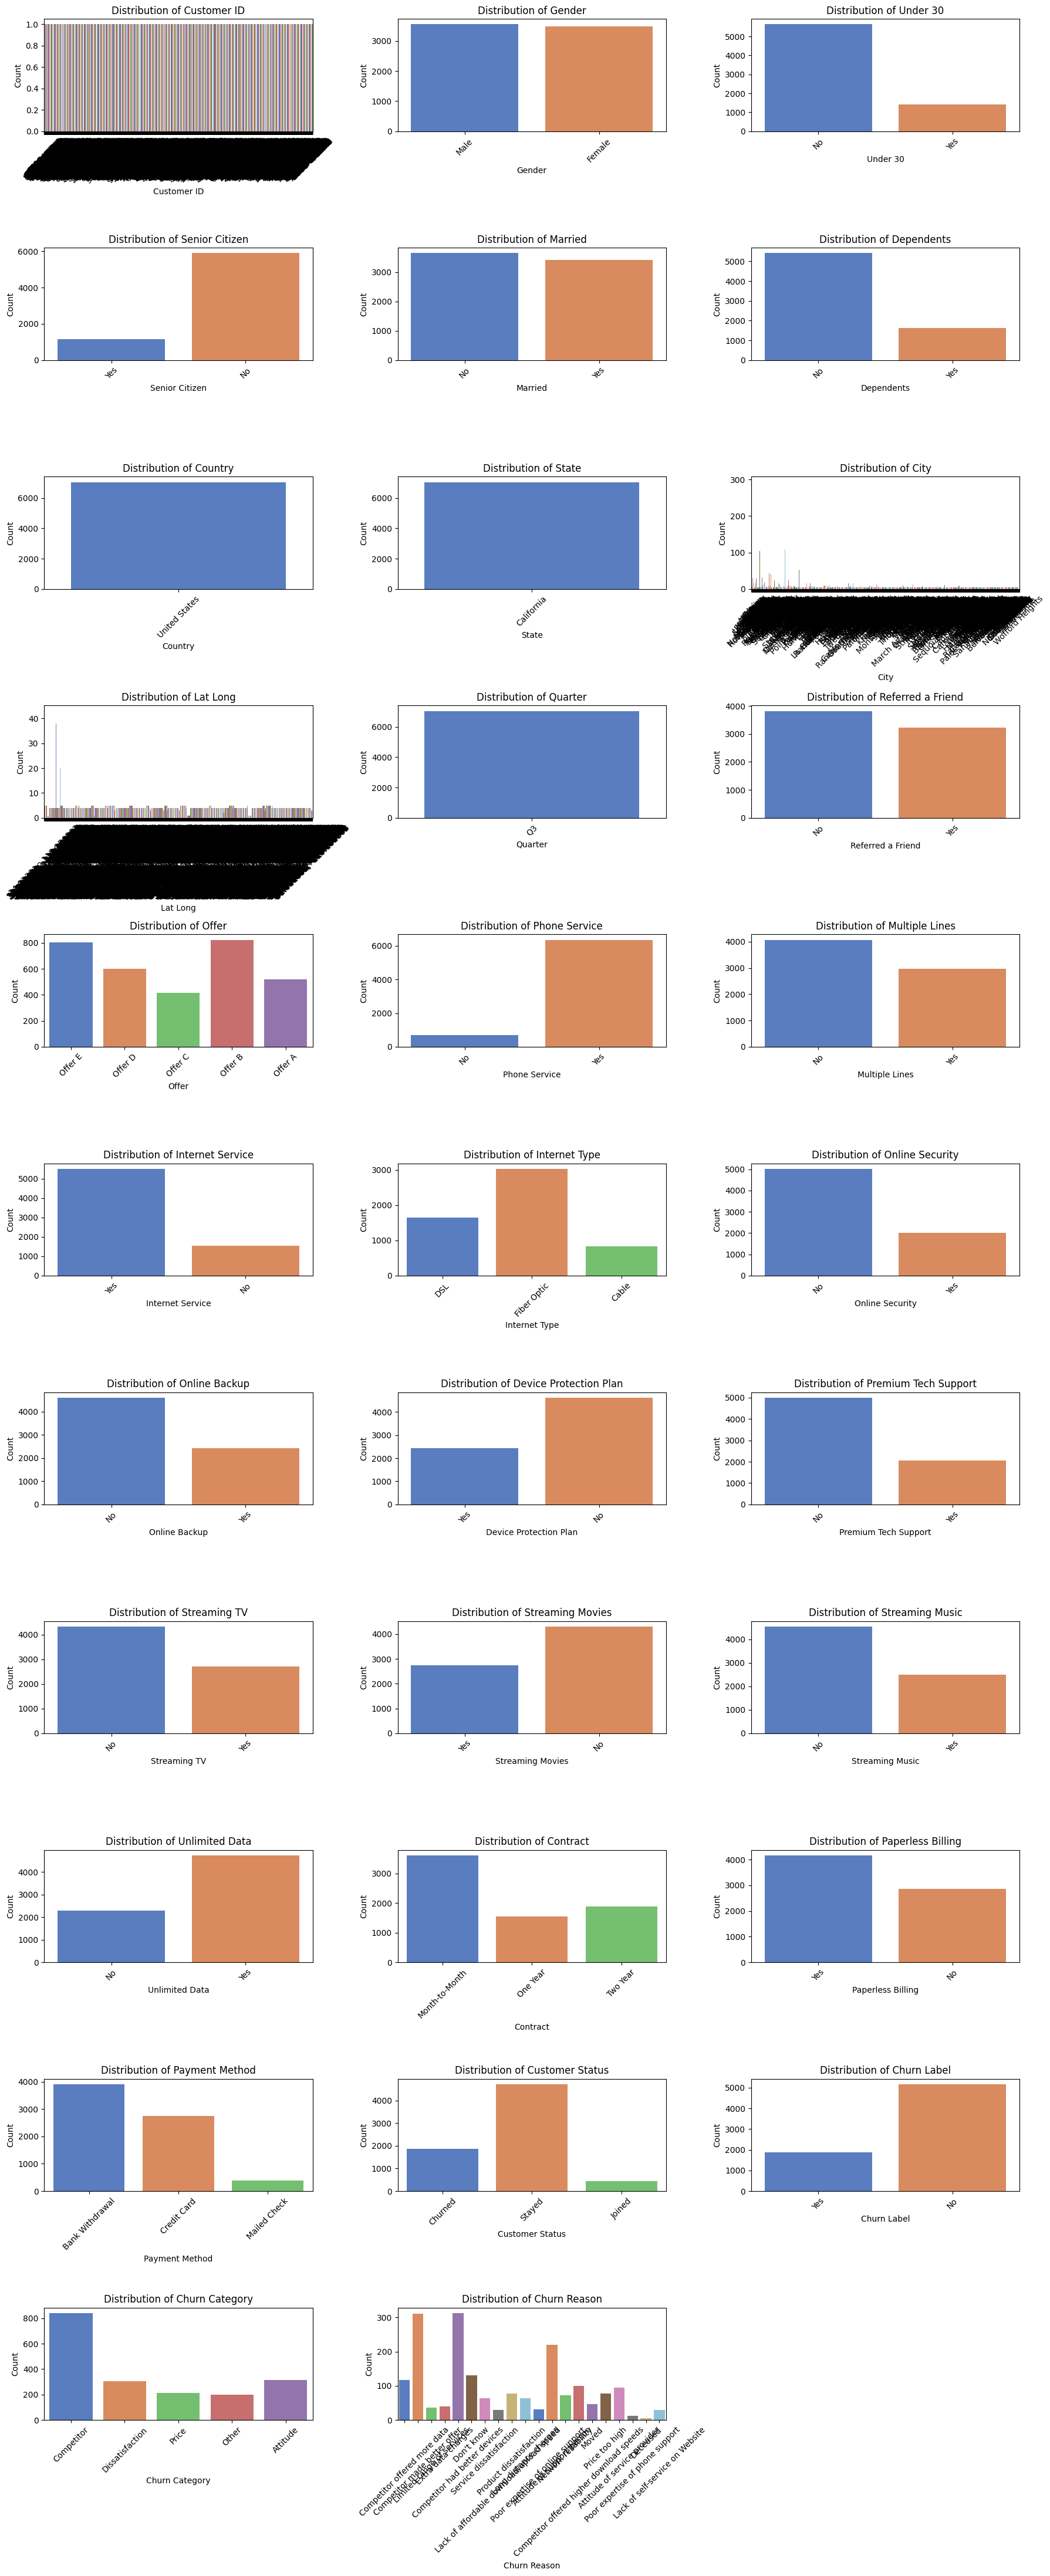

In [137]:

# Switcher vers catégorielle
analyzer.set_strategy(CategoricalUnivariateAnalysis())

# Toutes les variables catégorielles
analyzer.execute_analysis(df)
